#1) Write a Bash script that
- Creates a directory named "backup" in the user's home directory^
- Copies all .txt files from the current directory into the "backup" directory^
- Appends the current date and time to the filenames of the copied files.

In [ ]:
#create vim folder in git bash
vim bk.sh




In [ ]:
#type code in vim
#!/bin/bash

# Create backup directory in user's home if it doesn't exist
BACKUP_DIR="$HOME/backup"
mkdir -p "$BACKUP_DIR"

# Loop through all .txt files in current directory
for file in *.txt; do
    # Check if .txt files exist
    [ -e "$file" ] || continue

    # Extract filename without extension
    filename=$(basename -- "$file" .txt)

    # Get current date and time
    timestamp=$(date +"%Y%m%d_%H%M%S")

    # Create new filename with timestamp
    new_filename="${filename}_${timestamp}.txt"

    # Copy file to backup directory with new name
    cp "$file" "$BACKUP_DIR/$new_filename"
done

echo "Backup completed successfully!"

In [ ]:
#press esc and :wq to save and exit
#chNge user mode
chmod +x bk.sh

#run file
bash bk.sh

#

#Task 2: System Health Check

Create a script thatg
- Checks the system’s CPU and memory usage^
- Reports if the CPU usage is above 80% or if the available memory is below 20%^
- Logs the results to a file named system_health.log.

In [ ]:
#create file
vim health.sh

In [ ]:
#!/bin/bash

LOGFILE="system_health.log"

# Get CPU usage
CPU=$(top -bn1 | grep "Cpu" | awk '{print 100 - $8}')

# Get memory usage (percentage of free memory)
MEM=$(free | awk '/Mem/ {print ($7/$2) * 100}')

# Get date
DATE=$(date)

# Log results
echo "----- $DATE -----" >> $LOGFILE
echo "CPU Usage: $CPU%" >> $LOGFILE
echo "Available Memory: $MEM%" >> $LOGFILE

# Check conditions
if (( $(echo "$CPU > 80" | bc -l) )); then
  echo "Warning: CPU usage is above 80%" >> $LOGFILE
fi

if (( $(echo "$MEM < 20" | bc -l) )); then
  echo "Warning: Available memory is below 20%" >> $LOGFILE
fi

echo "" >> $LOGFILE
echo "Check complete!"

In [ ]:
#run code
chmod +x health.sh #change mode to executable
./health.sh

In [ ]:
#output
----- Wed Mar 18 15:10:00 -----
CPU Usage: 45.2%
Available Memory: 30.5%

#Task 3: User Account Management

Write a script thatg
- Reads a list of usernames from a file (e.g., user_list.txt)^
- Creates a new user for each username^
- Generates a random password for each user and saves the username and password to a file named
credentials.txt.

In [ ]:
#create
vim safe.sh

In [ ]:
#code
#!/bin/bash

input_file="user_list.txt"
output_file="credentials.txt"

> "$output_file"

while IFS= read -r username; do
  [ -z "$username" ] && continue
  password=$(openssl rand -base64 12 | tr -dc 'A-Za-z0-9!@#$%^&*()') # safe chars

  # Only log credentials; no system user creation
  echo "$username:$password" >> "$output_file"
  echo "Credentials created for $username"
done < "$input_file"

echo "Done. Check $output_file for credentials."

In [ ]:
#create user_list.txt in same folder or same path where safe.sh is saved
/C:/Users/Dell
#and run
bash safe.sh



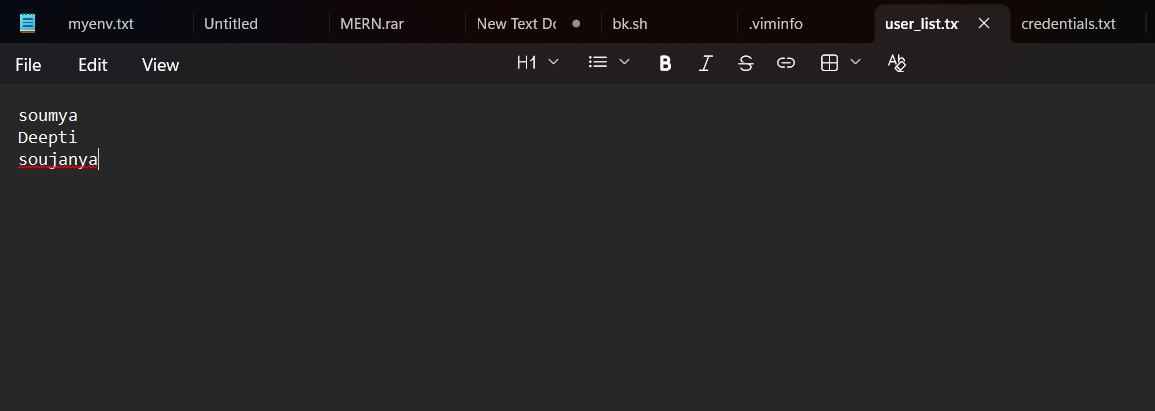

In [ ]:
#output is saved in creadential.txt


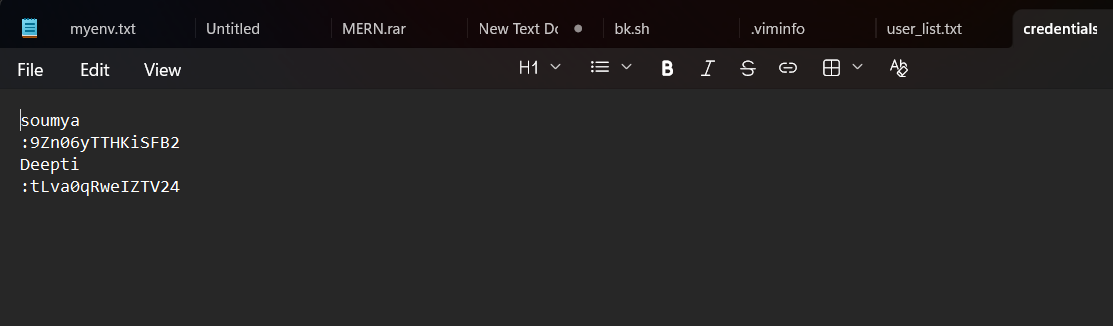

#Task 4: Automated Backup

Create a script thatg
- Takes a directory path as input from the user^
- Compresses the directory into a .tar.gz file^
- Saves the compressed file with a name that includes the current date (e.g., backup_2023-08-20.tar.gz).

In [ ]:
#create file
vim backup.sh

In [ ]:
#!/bin/bash

# Ask user for directory to back up
read -p "Enter the full path of the directory to back up: " dir_path

# Check if directory exists
if [ ! -d "$dir_path" ]; then
    echo "Error: Directory does not exist."
    exit 1
fi

# Get current date
current_date=$(date +"%Y-%m-%d")

# Get directory name without path
dir_name=$(basename "$dir_path")

# Output file name
backup_file="${dir_name}_backup_${current_date}.tar.gz"

# Create backup
tar -czf "$backup_file" -C "$(dirname "$dir_path")" "$dir_name"

echo "Backup successful! Saved as $backup_file"

In [ ]:
#change code and run
chomd +x backup.sh
bash backup.sh

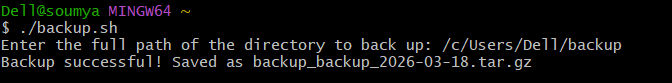

#Task 5: Simple To-Do List

Create a Bash script thatg
- Implements a simple command-line to-do list^
- Allows the user to add tasks, view tasks, and remove tasks^
- Saves the tasks to a file (e.g., todo.txt).

In [ ]:
#create file
vim todo.sh


In [ ]:
#!/bin/bash

TODO_FILE="todo.txt"

# Create todo file if it doesn't exist
touch "$TODO_FILE"

# Function to display menu
show_menu() {
    echo "====================="
    echo " Simple To-Do List"
    echo "====================="
    echo "1) Add Task"
    echo "2) View Tasks"
    echo "3) Remove Task"
    echo "4) Exit"
    echo "====================="
}

# Function to add a task
add_task() {
    read -p "Enter a new task: " task
    echo "$task" >> "$TODO_FILE"
    echo "Task added!"
}

# Function to view tasks
view_tasks() {
    if [ ! -s "$TODO_FILE" ]; then
        echo "No tasks found."
    else
        echo "Your tasks:"
        nl -w3 -s". " "$TODO_FILE"
    fi
}

# Function to remove a task
remove_task() {
    view_tasks
    read -p "Enter the task number to remove: " task_number
    if [[ "$task_number" =~ ^[0-9]+$ ]]; then
        sed -i "${task_number}d" "$TODO_FILE"
        echo "Task removed!"
    else
        echo "Invalid number!"
    fi
}

# Main loop
while true; do
    show_menu
    read -p "Choose an option [1-4]: " choice
    case $choice in
        1) add_task ;;
        2) view_tasks ;;
        3) remove_task ;;
        4) echo "Goodbye!"; exit 0 ;;
        *) echo "Invalid option, try again." ;;
    esac
done

In [ ]:
#after typing esc :wq
#to save and exit
#then chnage mode
chmod +x todo.sh
./todo.sh

output
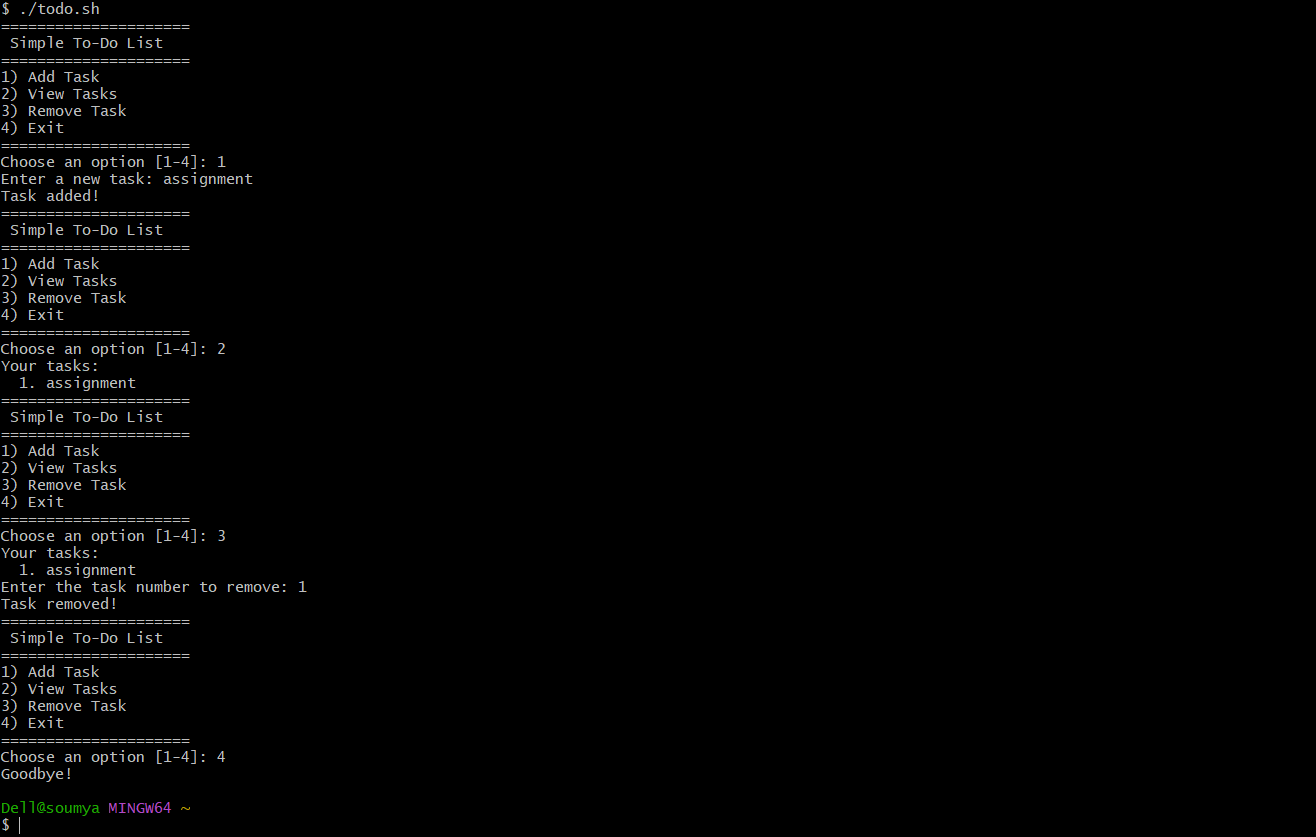

#Task 6: Automated Software Installation

Write a script thatg
- Reads a list of software package names from a file (e.g., packages.txt)^
- Installs each package using the appropriate package manager (apt, yum, etc.)^
- Logs the installation status of each package.

In [ ]:
vim install.sh


In [ ]:
#!/bin/bash

PACKAGE_FILE="packages.txt"
LOG_FILE="install_log.txt"

> "$LOG_FILE"

while IFS= read -r package; do
    [ -z "$package" ] && continue
    echo "Installing $package..."

    # Accept agreements automatically
    winget install --id "$package" -e --silent --accept-source-agreements --accept-package-agreements 2>> "$LOG_FILE"

    if [ $? -eq 0 ]; then
        echo "$package installed successfully." | tee -a "$LOG_FILE"
    else
        echo "Failed to install $package." | tee -a "$LOG_FILE"
    fi
done < "$PACKAGE_FILE"

echo "All installations attempted. Check $LOG_FILE for details."

create file packages.txt in same path or folder
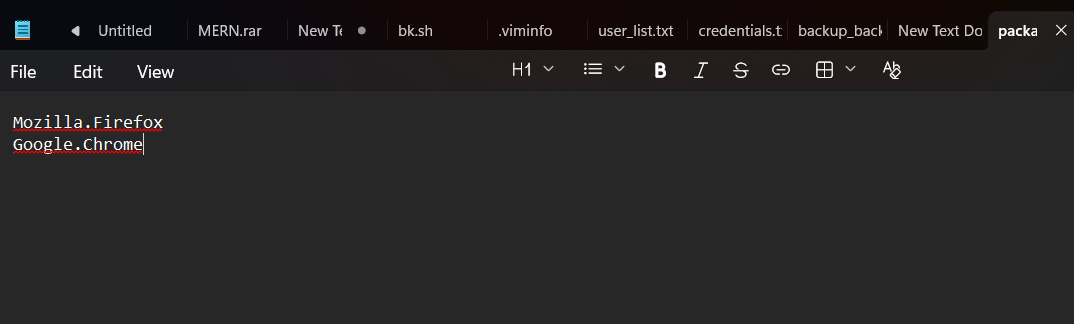

In [ ]:
chmod +x install.sh
./install.sh

output:
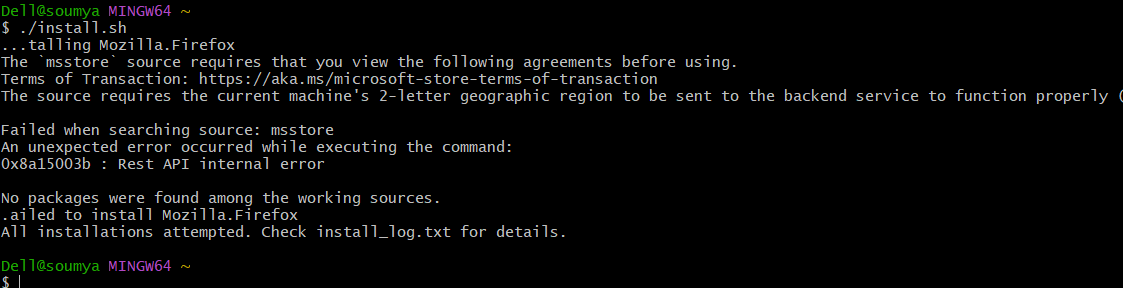

#Task 7: Text File Processing

Create a script thatg
- Takes a text file as input^
- Counts and displays the number of lines, words, and characters in the file^
- Finds and displays the longest word in the file.

In [ ]:
vim test.sh


In [ ]:
#!/bin/bash

# Ask user for the text file
read -p "Enter the full path of the text file: " file_path

# Check if file exists
if [ ! -f "$file_path" ]; then
    echo "Error: File does not exist."
    exit 1
fi

# Count lines, words, characters
lines=$(wc -l < "$file_path")
words=$(wc -w < "$file_path")
chars=$(wc -m < "$file_path")

echo "File statistics for '$file_path':"
echo "Lines: $lines"
echo "Words: $words"
echo "Characters: $chars"

# Find the longest word
longest_word=$(tr -s '[:space:][:punct:]' '\n' < "$file_path" | awk '{ if(length > L){ L=length; W=$0 } } END{ print W }')

echo "Longest word in the file: $longest_word"

In [ ]:
#create a file in same directory example.txt


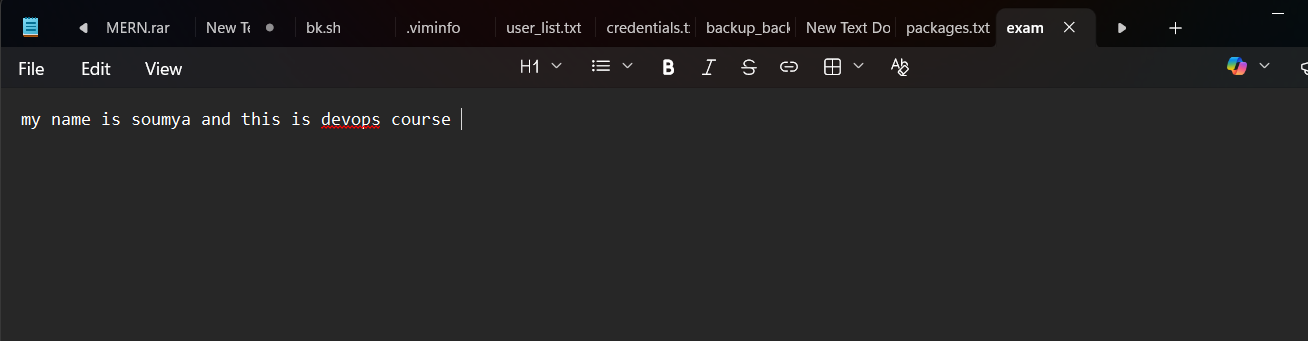

In [ ]:
#change mode
 chmod +x test.sh
 #run
 ./test.sh


outout
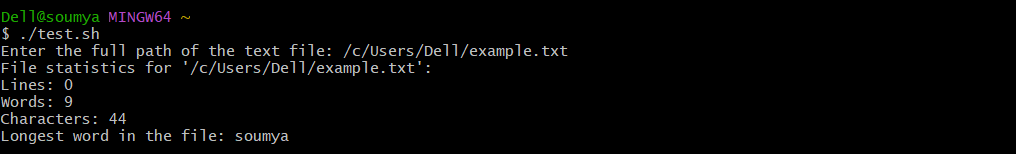